# Visión por Computadora I - CEIA

## Trabajo Práctico 2

Quiroga, Martin Gabriel
a2412

-----

### Objetivo
Implementar un detector de máximo enfoque sobre un video aplicando técnicas de análisis espectral similar al que utilizan las cámaras digitales modernas. El video a procesar será: "focus_video.mov".

#### 1. Se debe implementar un algoritmo que dad una imagen, o región, calcule la métrica propuesta en el paper "Image Sharpness Measure for Blurred Images in Frequency Domain" y realizar tres experimentos:
1. Medición sobre todo el frame
2. Medición sobre una ROI ubicada en el centro del frame. Area de la ROI = 5 o 10% del area total del frame.

Opcional:
Medición sobre una matriz de enfoque compuesta por un arreglo de NxM elementos rectangulares equiespaciados. N y M son valores arbitrarios, probar con varios valores 4x3, 7x5, etc... (al menos 3)

Para cada experimento se debe presentar:
- Una curva o varias curvas que muestren la evolución de la métrica frame a frame donde se vea claramente cuando el algoritmo detectó el punto de máximo enfoque.

> NOTA:
>
> El código a continuación se deja en el notebook porque fue parte del proceso que se siguió hasta desarrollar las funciones usadas finalmente.
>
> Se puede omitir sin ejecutar y saltar directamente a la resolución del ejercicio está en la sección [Resolución](#resolucion)

#### Desarrollo previo (se puede omitir)

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
video_path = "focus_video.mov"
captura = cv.VideoCapture(video_path)

# Visualizar el video
fps = int(captura.get(cv.CAP_PROP_FPS))
print(f"FPS del video: {fps}")
delay = int(600/fps)

frames = []
bgr_frames = []
if not captura.isOpened():
    print("Error al abrir el video")
else:
    while True:
        ret, frame = captura.read()
        if not ret:
            break
        cv.imshow("Video", frame)
        # Capturar los frames para después no tener que releer el video
        frames.append(cv.cvtColor(frame, cv.COLOR_BGR2GRAY))
        bgr_frames.append(frame)

        if cv.waitKey(delay) & 0xFF == ord('q'):
            break

captura.release()
cv.destroyAllWindows()
print(f"{len(frames)} frames")


In [ ]:
# Medición de sharpness(nitidez) sobre todo el frame
# Abrir el video nuevamente
captura = cv.VideoCapture(video_path)

# Obtener propiedades del video
frame_width = int(captura.get(cv.CAP_PROP_FRAME_WIDTH))
frame_height = int(captura.get(cv.CAP_PROP_FRAME_HEIGHT))

FM = []
for frame in frames:
    F = np.fft.fft2(frame)
    Fc = np.fft.fftshift(F) # Pasos 1 y 2
    AF = np.abs(Fc) # Paso 3
    M = np.max(AF) # Paso 4
    threshold = M * 0.001
    # F tiene valores complejos, pero es lo que indica el paper para usar
    # Analizar si lo correcto sería usar F o AF. Se termina usando AF
    Th = np.sum(np.where(AF > threshold, 1, 0)) # Paso 5

    FM.append(Th / (frame_width * frame_height))

max_focus_frame = np.argmax(FM)

plt.figure(figsize=(10, 5))
plt.scatter(
    range(len(FM)),
    FM,
    s=10,
    label="Image Quality Measure (FM)",

)
plt.vlines(max_focus_frame, min(FM), max(FM), colors='red', linestyles='dashed', label=f'Máximo enfoque: {max_focus_frame}')
# plt.plot(FM, label="Image Quality Measure (FM)")
plt.legend()
plt.grid()
plt.show()


In [ ]:
# Aplicarlo a una ROI en el centro
pcg = 0.05 # % del frame

ROI_width = int(frame_width * pcg)
ROI_height = int(frame_height * pcg)

ROI_center = (frame_width//2, frame_height//2)

x = ROI_center[0] - ROI_width//2
y = ROI_center[1] - ROI_height//2
w = ROI_width
h = ROI_height

print(x, y, w, h)
frame_con_roi = bgr_frames[0].copy()
cv.rectangle(frame_con_roi, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.figure(figsize=(8, 5))
plt.imshow(cv.cvtColor(frame_con_roi, cv.COLOR_BGR2RGB))
plt.show()

FM = []
for frame in frames:
    roi = frame[y:y+h, x:x+w]
    F = np.fft.fft2(roi)
    Fc = np.fft.fftshift(F) # Pasos 1 y 2
    AF = np.abs(Fc) # Paso 3
    M = np.max(AF) # Paso 4
    threshold = M * 0.001
    Th = np.sum(np.where(AF > threshold, 1, 0)) # Paso 5

    FM.append(Th / (w * h))

max_focus_frame = np.argmax(FM)

# cv.imshow("ROI", roi)
plt.figure(figsize=(10, 5))
plt.scatter(
    range(len(FM)),
    FM,
    s=10,
    label="Image Quality Measure (FM)"
)
plt.vlines(max_focus_frame, min(FM), max(FM), colors='red', linestyles='dashed', label=f'Máximo enfoque: {max_focus_frame}')
plt.legend()
plt.grid()
plt.show()


In [ ]:
# Aplicarlo a un conjunto de ROI. Tiene que ser generalizable en el sentido
# de poder cambiar la cantidad de regiones de forma sencilla

ROI_rows = 3
ROI_columns = 4

pcg = 0.05 # % del frame

ROI_width = int(frame_width * pcg)
ROI_height = int(frame_height * pcg)

distance = 0.5  # Separación entre ROIs indicada como proporción del tamaño
                # de la ROI.

def get_ROI_coords(frame_width, frame_height, rows, columns, roi_width, roi_height, distance):
    # Calcular distancia entre los vértices de distintas ROIs
    dx = int(roi_width * (1 + distance))
    dy = int(roi_height * (1 + distance))

    # Calcular coordenadas de la primera ROI (esquina superior izquierda)
    start_x = (frame_width - (columns - 1) * dx - roi_width) // 2
    start_y = (frame_height - (rows - 1) * dy - roi_height) // 2

    coords = []
    for row in range(rows):
        for col in range(columns):
            x = start_x + col * dx
            y = start_y + row * dy
            coords.append((x, y, roi_width, roi_height))
    return coords

def evaluate_roi(frames, f_width, f_height, N, M, percentage=0.05, distance=0.5):
    roi_width = int(f_width * percentage)
    roi_height = int(f_height * percentage)
    rois=get_ROI_coords(
        frame_width=f_width,
        frame_height=f_height,
        rows=N,
        columns=M,
        roi_width=roi_width,
        roi_height=roi_height,
        distance=distance
    )
    FM = []
    for frame in frames:
        Th = 0
        rois_area = 0
        for roi in rois:
            x, y, w, h = roi[0], roi[1], roi[2], roi[3]
            roi = frame[y:y+h, x:x+w]
            F = np.fft.fft2(roi)
            Fc = np.fft.fftshift(F) # Pasos 1 y 2
            AF = np.abs(Fc) # Paso 3
            MAF = np.max(AF) # Paso 4, se cambia el nombre de la variable por conflicto
            threshold = MAF * 0.001
            Th += np.sum(np.where(AF > threshold, 1, 0)) # Paso 5
            rois_area += w * h

        FM.append(Th / rois_area)

    return FM, rois

def plot_FM_and_ROIs(FM, frame, ROIs, umbral=None):
    max_focus_frame = np.argmax(FM)
    
    plt.figure(figsize=(10, 5))
    plt.scatter(
        range(len(FM)),
        FM,
        s=10,
        label="Image Quality Measure (FM)"
    )
    plt.vlines(max_focus_frame, min(FM), max(FM), colors='red', linestyles='dashed', label=f'Max Focus Frame: {max_focus_frame}')
    plt.legend()
    plt.grid()
    plt.show()
    
    frame_con_rois = frame.copy()
    for roi in ROIs:
        cv.rectangle(frame_con_rois, (roi[0], roi[1]), (roi[0]+roi[2], roi[1]+roi[3]), (0, 255, 0), 2)

    plt.figure(figsize=(8, 5))
    plt.imshow(cv.cvtColor(frame_con_rois, cv.COLOR_BGR2RGB))
    plt.show()

def plot_FM(FM, umbral=None):
    max_focus_frame = np.argmax(FM)
    
    plt.figure(figsize=(10, 5))
    plt.scatter(
        range(len(FM)),
        FM,
        s=10,
        label="Image Quality Measure (FM)"
    )
    plt.vlines(
        max_focus_frame,
        min(FM),
        max(FM),
        colors='red',
        linestyles='dashed',
        alpha=0.5,
        label=f'Max Focus Frame: {max_focus_frame}'
    )
    if umbral is not None:
        plt.plot(umbral, color='red', label="Umbral de nitidez")
        indices = np.where(umbral != None)[0]
        umbral_value = umbral[indices[0]]
        plt.vlines(indices[0], umbral_value*0.95, umbral_value*1.05, color='red')
        plt.vlines(indices[-1], umbral_value*0.95, umbral_value*1.05, color='red')
    plt.grid()
    plt.legend()
    plt.show()

def plot_ROIs(frame, ROIs):
    frame_con_rois = frame.copy()
    for roi in ROIs:
        cv.rectangle(frame_con_rois, (roi[0], roi[1]), (roi[0]+roi[2], roi[1]+roi[3]), (0, 255, 0), 2)

    plt.figure(figsize=(8, 5))
    plt.imshow(cv.cvtColor(frame_con_rois, cv.COLOR_BGR2RGB))
    plt.show()

FM1, rois1 = evaluate_roi(frames, frame_width, frame_height, 4, 3, distance=0.5)
# plot_FM_and_ROIs(FM1, bgr_frames[0].copy(), rois1)
sharp = define_sharpness_zone(FM1, 0.85)
plot_FM(FM1, umbral=sharp)
plot_ROIs(bgr_frames[0], rois1)


In [ ]:
# FM2, rois2 = evaluate_roi(frames, frame_width, frame_height, 7, 7, distance=0.5)
# plot_FM_and_ROIs(FM2, bgr_frames[0].copy(), rois2)

# FM3, rois3 = evaluate_roi(frames, frame_width, frame_height, 11, 9, distance=0.5)
# plot_FM_and_ROIs(FM3, bgr_frames[0].copy(), rois3)

Se desarrollaron las funciones anteriores para simplificar las pruebas con distintas matrices de ROIs, pero se pudo generalizar incluso para incluir el caso de querer tomar una sola ROI y del tamaño que se quiera, incluido el tamaño del frame completo.
```python
FM, rois = evaluate_roi(frames, frame_width, frame_height, 1, 1, percentage=1.0, distance=0.0)
plot_FM_and_ROIs(FM, bgr_frames[0].copy(), rois)
```

In [1]:
# FM4, rois4 = evaluate_roi(frames, frame_width, frame_height, 1, 1, percentage=1.0, distance=0.0)
# plot_FM_and_ROIs(FM4, bgr_frames[0].copy(), rois4)

In [ ]:
# Para definir la zona en la que el video se considera nítido se puede considerar un margen de 
# algun porcentaje del valor máximo medido.

def define_sharpness_zone(FM, th_pcg):
    umbral = np.max(FM) * th_pcg
    # print(f"Umbral: {umbral}")
    return np.where(FM >= umbral, umbral, None)


FM4, rois4 = evaluate_roi(frames, frame_width, frame_height, 1, 1, percentage=1.0, distance=0.0)
sharp_zone = define_sharpness_zone(FM4, 0.85)
plot_FM(FM4, sharp_zone)
plot_ROIs(bgr_frames[0].copy(), rois4)


### Resolucion

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

video_path = "focus_video.mov"
captura = cv.VideoCapture(video_path)

# Visualizar el video
fps = int(captura.get(cv.CAP_PROP_FPS))
print(f"FPS del video: {fps}")
delay = int(600/fps)

frames = []
bgr_frames = []
if not captura.isOpened():
    print("Error al abrir el video")
else:
    while True:
        ret, frame = captura.read()
        if not ret:
            break
        # cv.imshow("Video", frame)
        # Capturar los frames para después no tener que releer el video
        frames.append(cv.cvtColor(frame, cv.COLOR_BGR2GRAY))
        bgr_frames.append(frame)

        if cv.waitKey(delay) & 0xFF == ord('q'):
            break

frame_width = int(captura.get(cv.CAP_PROP_FRAME_WIDTH))
frame_height = int(captura.get(cv.CAP_PROP_FRAME_HEIGHT))
print(frame_width, " x ", frame_height)
captura.release()
cv.destroyAllWindows()
print(f"{len(frames)} frames")


FPS del video: 29
640  x  360
171 frames


In [2]:
# Definición de funciones desarrolladas
def get_ROI_coords(frame_width, frame_height, rows, columns, roi_width, roi_height, distance):
    """
    Calcula las coordenadas de múltiples ROIs regulares y equiespaciadas.
    Args:
        frame_width: ancho del frame
        frame_height: alto del frame
        rows: cantidad de filas de ROIs
        columns: cantidad de columnas de ROIs
        roi_width: ancho de la región
        roi_height: alto de la región
        distance: separación entre ROIs, indicada como proporción del tamaño de la ROI
    Returns:
        Lista de tuplas (x, y, width, height) con las coordenadas de cada ROI
    """
    # Calcular distancia entre los vértices de distintas ROIs
    dx = int(roi_width * (1 + distance))
    dy = int(roi_height * (1 + distance))

    # Calcular coordenadas de la primera ROI (esquina superior izquierda)
    start_x = (frame_width - (columns - 1) * dx - roi_width) // 2
    start_y = (frame_height - (rows - 1) * dy - roi_height) // 2

    coords = []
    for row in range(rows):
        for col in range(columns):
            x = start_x + col * dx
            y = start_y + row * dy
            coords.append((x, y, roi_width, roi_height))
    return coords

def evaluate_roi(frames, f_width, f_height, N, M, percentage=0.05, distance=0.5):
    """
    Evalúa la nitidez de un video en múltiples ROIs.
    Args:
        frames: lista de frames del video
        f_width: ancho de los frames
        f_height: alto de los frames
        N: cantidad de filas de ROIs
        M: cantidad de columnas de ROIs
        percentage: tamaño de las ROIs, indicado como porcentaje del tamaño del frame
        distance: separación entre ROIs, indicada como proporción del tamaño de la ROI
    Returns:
        FM: lista con la medida de nitidez para cada frame
        rois: lista de tuplas (x, y, width, height) con las coordenadas de cada ROI
    """
    roi_width = int(f_width * percentage)
    roi_height = int(f_height * percentage)
    rois=get_ROI_coords(
        frame_width=f_width,
        frame_height=f_height,
        rows=N,
        columns=M,
        roi_width=roi_width,
        roi_height=roi_height,
        distance=distance
    )
    FM = []
    for frame in frames:
        Th = 0
        rois_area = 0
        for roi in rois:
            x, y, w, h = roi[0], roi[1], roi[2], roi[3]
            roi = frame[y:y+h, x:x+w]
            F = np.fft.fft2(roi)
            Fc = np.fft.fftshift(F) # Pasos 1 y 2
            AF = np.abs(Fc) # Paso 3
            MAF = np.max(AF) # Paso 4, se cambia el nombre de la variable por conflicto
            threshold = MAF * 0.001
            Th += np.sum(np.where(AF > threshold, 1, 0)) # Paso 5
            rois_area += w * h
        
        # Se suman todos los pixeles que superan el umbra del su ROI y se divide por el
        # area total entre todas las ROIs. Debería funcionar igual que promediarlos ya
        # todas tienen el mismo tamaño.
        FM.append(Th / rois_area)

    return FM, rois


# Para definir la zona en la que el video se considera nítido se puede considerar un margen de 
# algun porcentaje del valor máximo medido.
def define_sharpness_zone(FM, th_pcg):
    """
    Define la zona de nitidez en función de un porcentaje del valor máximo alcanzado.
    Args:
        FM: lista con la medida de nitidez para cada frame
        th_pcg: porcentaje del valor máximo a considerar como umbral
    Returns:
        Lista con el valor del umbral para los frames que superan dicho valor
    """
    umbral = np.max(FM) * th_pcg
    print(f"Umbral: {umbral}")
    return np.where(FM >= umbral, umbral, None)


def plot_FM(FM, umbral=None, ax=None, color='steelblue'):
    """
    Grafica la medida de nitidez para cada frame y marca los frames con mayor nitidez.
    Args:
        FM: lista con la medida de nitidez para cada frame
        umbral: lista con los frames que superan el umbral de nitidez
    """
    max_focus_frame = np.argmax(FM)

    if ax is None:
        plt.figure(figsize=(10, 5))
        ax = plt.gca()
    
    ax.scatter(
        range(len(FM)),
        FM,
        s=10,
        label="Enfoque de la imagen",
        color=color
    )
    ax.vlines(
        max_focus_frame,
        min(FM),
        max(FM),
        colors=color,
        linestyles='dashed',
        alpha=0.5,
        label=f'Max Focus Frame: {max_focus_frame}'
    )
    if umbral is not None:
        ax.plot(umbral, color=color, alpha=0.7, label="Umbral de nitidez")
        indices = np.where(np.array(umbral) != None)[0]
        umbral_value = umbral[indices[0]]
        plt.vlines(indices[0], umbral_value*0.95, umbral_value*1.05, color=color)
        plt.vlines(indices[-1], umbral_value*0.95, umbral_value*1.05, color=color)
    ax.grid()
    ax.legend()

def plot_ROIs(frame, ROIs, ax=None):
    """
    Grafica los frames con las ROIs superpuestas.
    Args:
        frame: frame del video
        ROIs: lista de tuplas (x, y, width, height) con las coordenadas de cada ROI
    """
    frame_con_rois = frame.copy()
    for roi in ROIs:
        cv.rectangle(frame_con_rois, (roi[0], roi[1]), (roi[0]+roi[2], roi[1]+roi[3]), (0, 255, 0), 2)

    if ax is None:
        plt.figure(figsize=(8, 5))
        ax = plt.gca()

    ax.imshow(cv.cvtColor(frame_con_rois, cv.COLOR_BGR2RGB))
    ax.axis('off')


#### Frame completo

Umbral: 0.021468098958333334


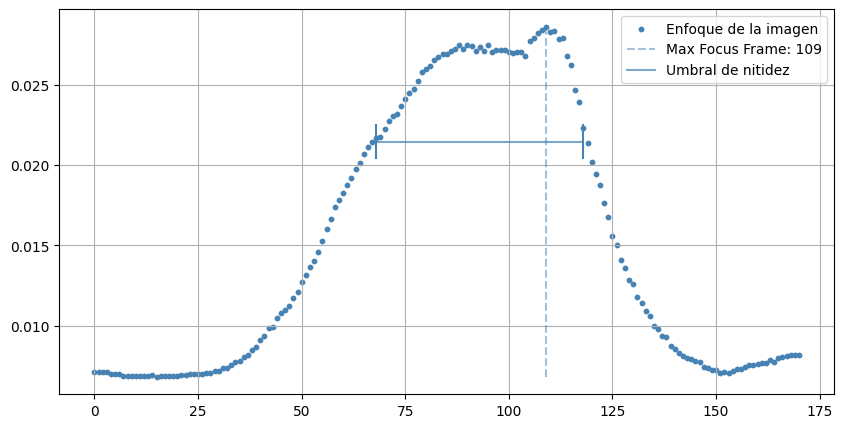

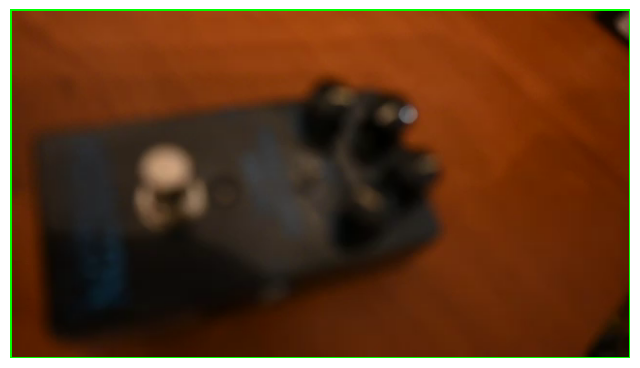

In [3]:
fm1, rois1 = evaluate_roi(frames, frame_width, frame_height, 1, 1, percentage=1.0, distance=0.0)
sharp_zone1 = define_sharpness_zone(fm1, 0.75)
plot_FM(fm1, sharp_zone1)
plot_ROIs(bgr_frames[0].copy(), rois1)

#### Una sola ROI

Umbral: 0.5540364583333334


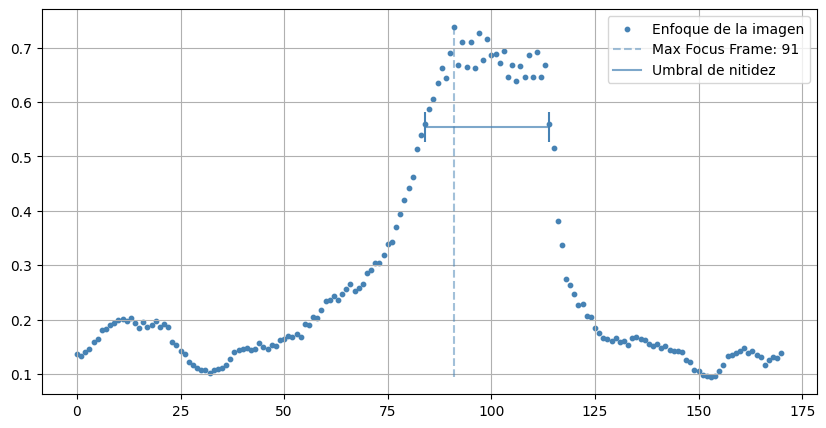

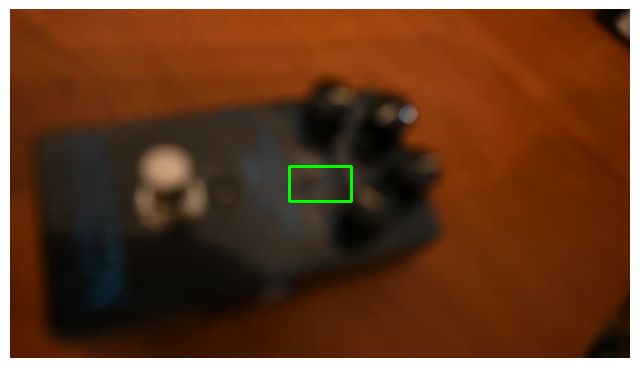

In [4]:
fm2, rois2 = evaluate_roi(frames, frame_width, frame_height, 1, 1, percentage=0.1, distance=0.0)
sharp_zone2 = define_sharpness_zone(fm2, 0.75)
plot_FM(fm2, sharp_zone2)
plot_ROIs(bgr_frames[0].copy(), rois2)

#### Múltiples ROIs
- 4x3
- 7x7
- 11x9

Umbral: 0.6614583333333333


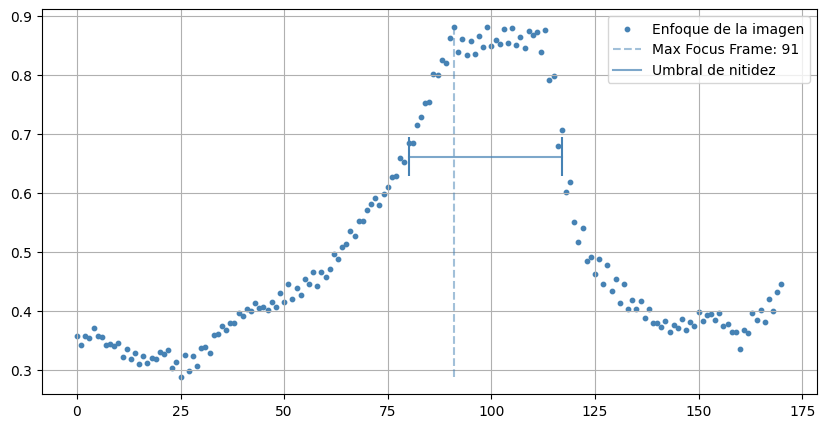

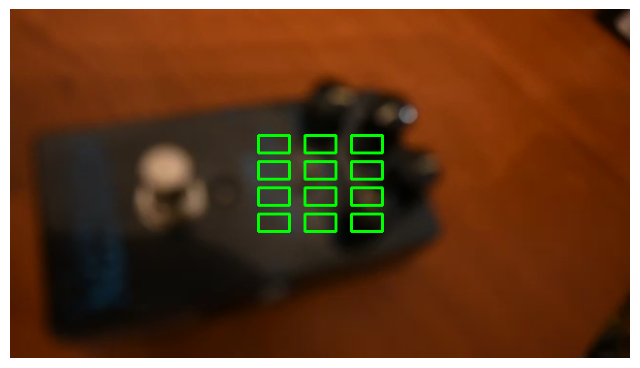

In [5]:
fm3, rois3 = evaluate_roi(frames, frame_width, frame_height, 4, 3, percentage=0.05, distance=0.5)
sharp_zone3 = define_sharpness_zone(fm3, 0.75)
plot_FM(fm3, sharp_zone3)
plot_ROIs(bgr_frames[0].copy(), rois3)

Umbral: 0.5294961734693877


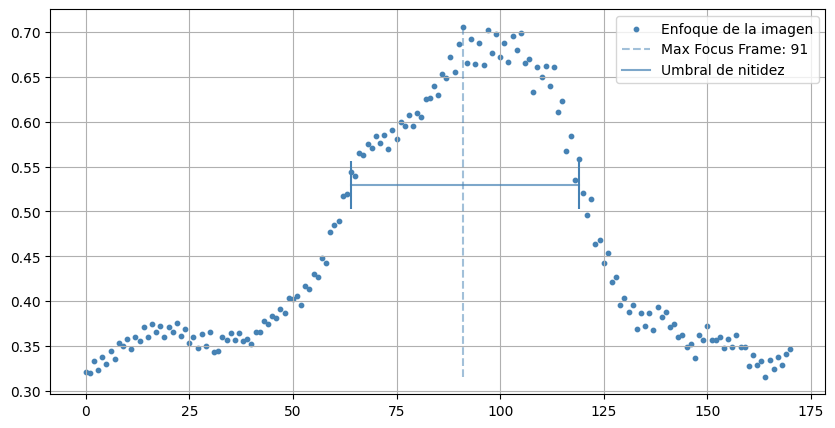

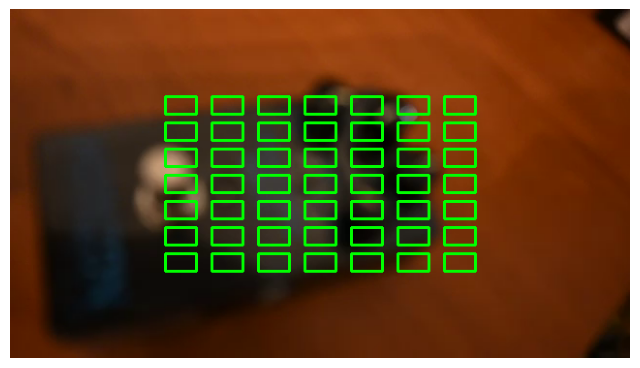

In [6]:
fm4, rois4 = evaluate_roi(frames, frame_width, frame_height, 7, 7, percentage=0.05, distance=0.5)
sharp_zone4 = define_sharpness_zone(fm4, 0.75)
plot_FM(fm4, sharp_zone4)
plot_ROIs(bgr_frames[0].copy(), rois4)

Umbral: 0.40653935185185186


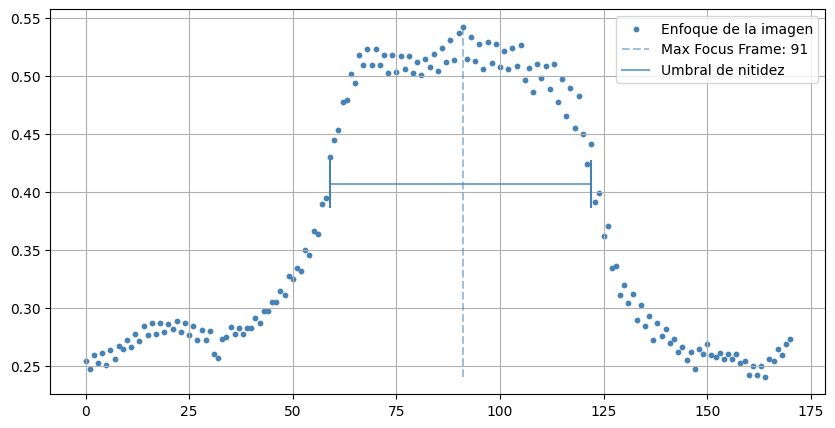

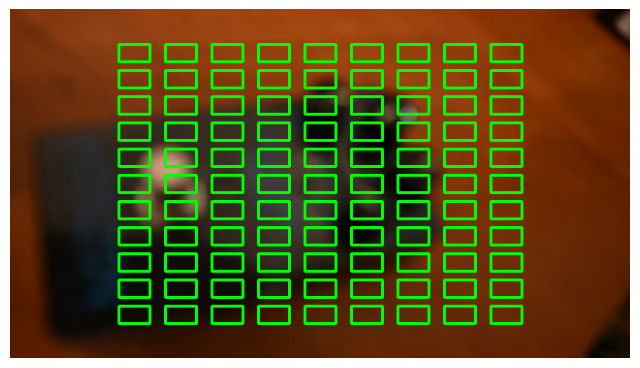

In [7]:
fm5, rois5 = evaluate_roi(frames, frame_width, frame_height, 11, 9, percentage=0.05, distance=0.5)
sharp_zone5 = define_sharpness_zone(fm5, 0.75)
plot_FM(fm5, sharp_zone5)
plot_ROIs(bgr_frames[0].copy(), rois5)

#### 2. Cambiar la métrica de enfoque eligiendo uno de los algoritmos explicados en el apéndice de: Analysis of focus measure operators in shape-from-focus.

Se elige la métrica A.20 del artículo, identificada como *Variance of Laplacian (LAP4)*.

In [8]:
# Se usa la misma estrategia que para la métrica anterior en cuanto al manejo de ROIs

def evaluate_roi_with_lap4(frames, f_width, f_height, N, M, percentage=0.05, distance=0.5):
    """
    Evalúa la nitidez de un video en múltiples ROIs utilizando la métrica Variance of Laplacian.
    Args:
        frames: lista de frames del video en escala de grises
        f_width: ancho de los frames
        f_height: alto de los frames
        N: cantidad de filas de ROIs
        M: cantidad de columnas de ROIs
        percentage: tamaño de las ROIs, indicado como porcentaje del tamaño del frame
        distance: separación entre ROIs, indicada como proporción del tamaño de la ROI
    Returns:
        FM: lista con la medida de nitidez para cada frame
        rois: lista de tuplas (x, y, width, height) con las coordenadas de cada ROI
    """
    roi_width = int(f_width * percentage)
    roi_height = int(f_height * percentage)
    rois=get_ROI_coords(
        frame_width=f_width,
        frame_height=f_height,
        rows=N,
        columns=M,
        roi_width=roi_width,
        roi_height=roi_height,
        distance=distance
    )
    scores = []
    for frame in frames:
        coeff = []
        for roi in rois:
            x, y, w, h = roi[0], roi[1], roi[2], roi[3]
            roi = frame[y:y+h, x:x+w]
            # Se aplica la transformada de Laplace al ROI
            # Se debe transformar a float 64 para evitar el
            # truncamiento de valores negativos
            laplacian = cv.Laplacian(roi, cv.CV_64F)
            coeff.append(laplacian.ravel())
        
        # Se agregan todos los coeficientes de todas las ROIs en un solo arreglo
        # para poder calcular luego la varianza de todas las ROIs juntas. Si se
        # usa el promedio, el resultado puede diferir si el brillo es distinto
        # entre las regiones.
        all_coeff = np.concatenate(coeff)
        variance = float(all_coeff.var())

        scores.append(variance)

    return scores, rois

Umbral: 81.69536722139429


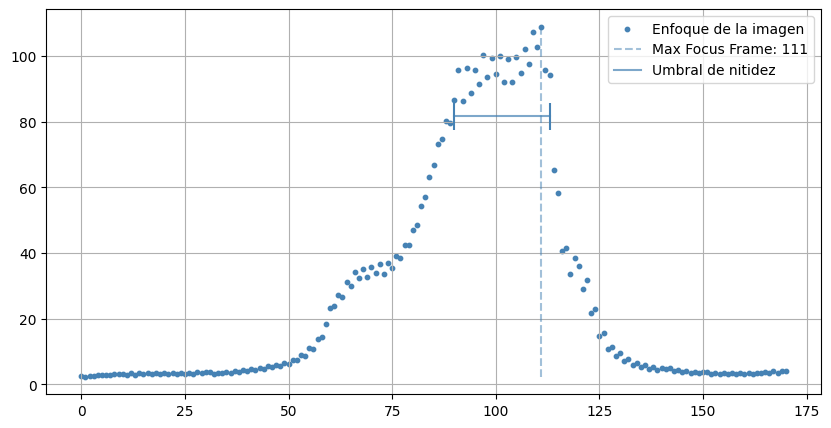

In [9]:
scores1, rois1  = evaluate_roi_with_lap4(frames, frame_width, frame_height, 1, 1, percentage=1.0, distance=0.0)
sharp_zone_lap1 = define_sharpness_zone(scores1, 0.75)
plot_FM(scores1, sharp_zone_lap1)

Umbral: 460.139108022054


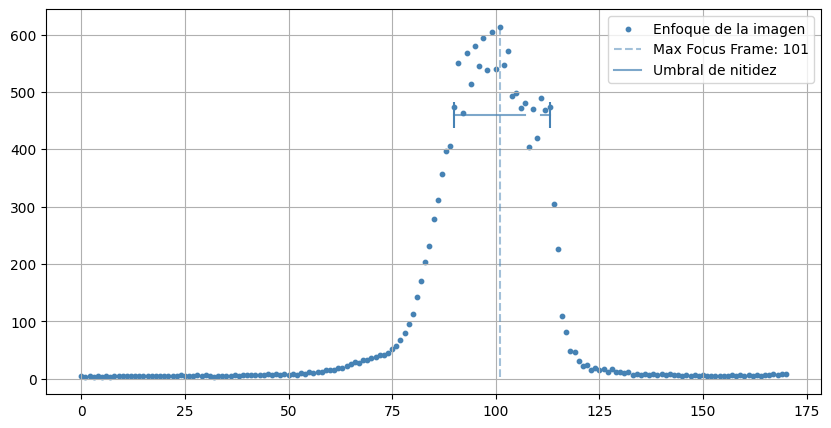

In [10]:
scores2, rois2 = evaluate_roi_with_lap4(frames, frame_width, frame_height, 1, 1, percentage=0.1, distance=0.0)
sharp_zone_lap2 = define_sharpness_zone(scores2, 0.75)
plot_FM(scores2, sharp_zone_lap2)

Umbral: 370.4697686968517


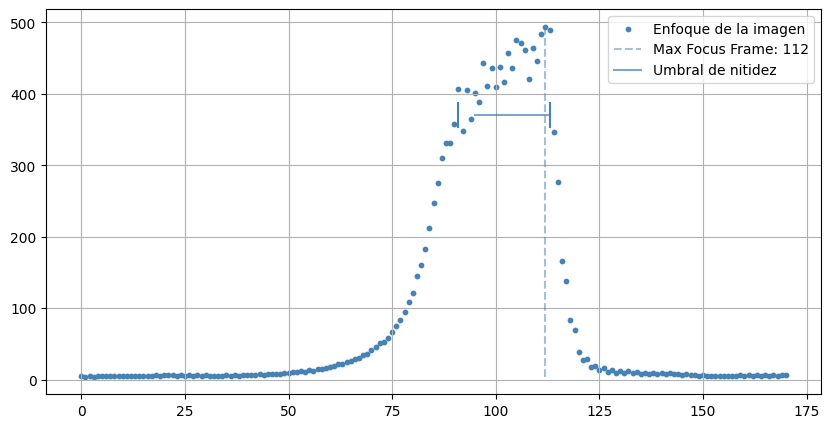

In [11]:
scores3, rois3 = evaluate_roi_with_lap4(frames, frame_width, frame_height, 4, 3, percentage=0.05, distance=0.5)
sharp_zone_lap3 = define_sharpness_zone(scores3, 0.75)
plot_FM(scores3, sharp_zone_lap3)

Umbral: 261.4588476896547


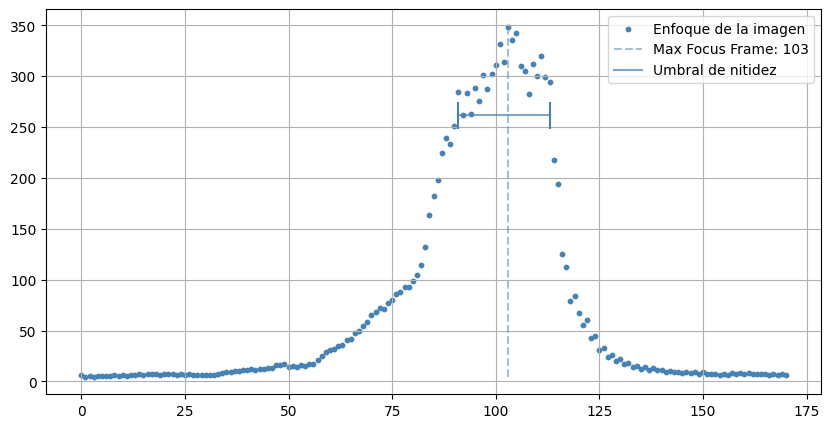

In [12]:
scores4, rois4 = evaluate_roi_with_lap4(frames, frame_width, frame_height, 7, 7, percentage=0.05, distance=0.5)
sharp_zone_lap4 = define_sharpness_zone(scores4, 0.75)
plot_FM(scores4, sharp_zone_lap4)

Umbral: 145.73709217582083


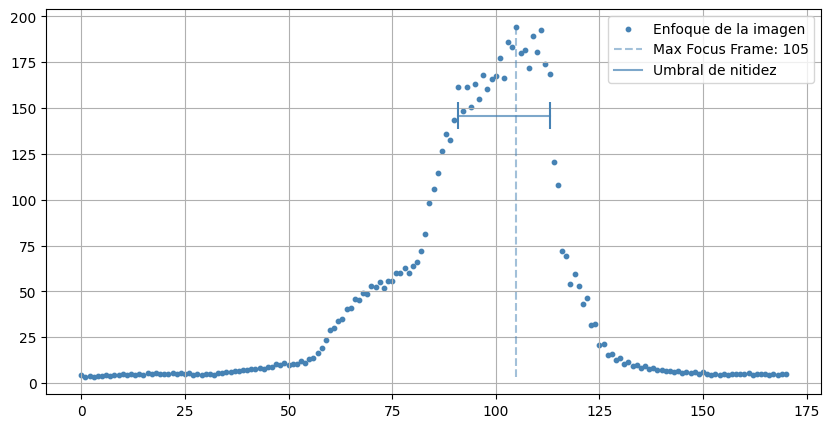

In [13]:
scores5, rois5 = evaluate_roi_with_lap4(frames, frame_width, frame_height, 11, 9, percentage=0.05, distance=0.5)
sharp_zone_lap5 = define_sharpness_zone(scores5, 0.75)
plot_FM(scores5, sharp_zone_lap5)

Es difícil comparar las métricas, ya que con el primer algoritmo se obtienen valores de 0 a 1, ya que se conforma mediante una fracción de pixeles, mientras que para el segundo (Varianza de Laplacianos) se trata de una varianza cuyos valores pueden ir de 0 a miles. A continuación, se normalizarán ambos a un mismo rango y se graficarán juntos para así al menos comparar las formas de las curvas logradas.

In [14]:
def normalizar(x):
    x = np.array(x, dtype=float)
    return (x - x.min()) / (x.max() - x.min())

Umbral: 0.75
Umbral: 0.75


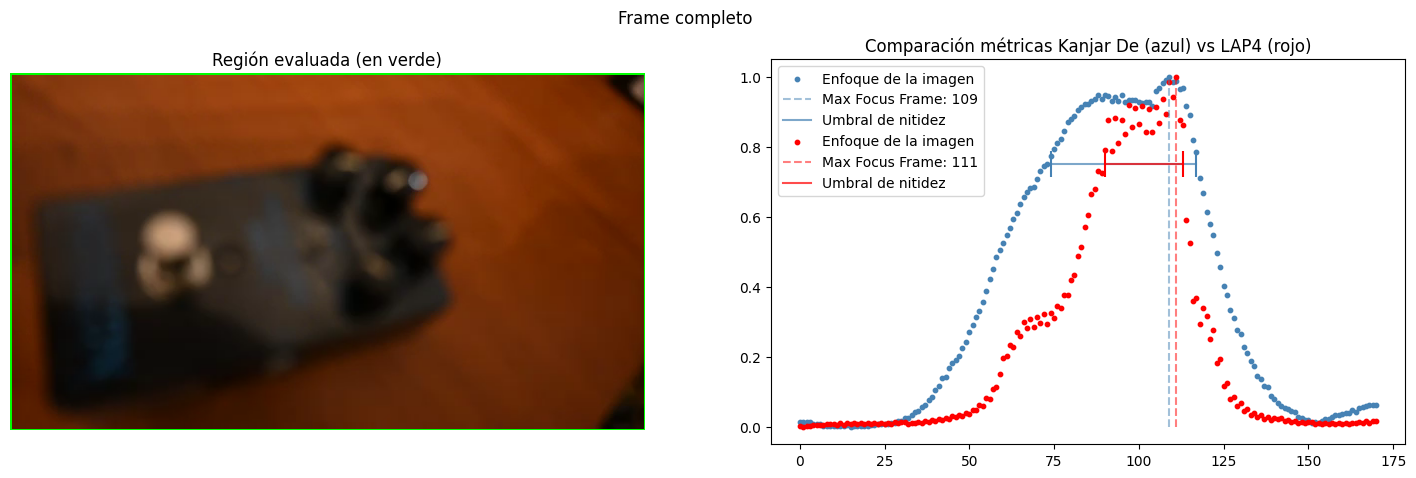

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18,5))

plot_ROIs(bgr_frames[0].copy(), rois1, ax=axes[0])
axes[0].set_title("Región evaluada (en verde)")

# Normalización
fm1_norm = normalizar(fm1)
focus_fm1_norm = define_sharpness_zone(fm1_norm, 0.75)
scores1_norm = normalizar(scores1)
focus_scores1_norm = define_sharpness_zone(scores1_norm, 0.75)
plot_FM(fm1_norm, focus_fm1_norm, ax=axes[1], color='steelblue')
plot_FM(scores1_norm, focus_scores1_norm, ax=axes[1], color='red')
axes[1].set_title("Comparación métricas Kanjar De (azul) vs LAP4 (rojo)")

plt.suptitle("Frame completo")
plt.show()

Umbral: 0.75
Umbral: 0.75


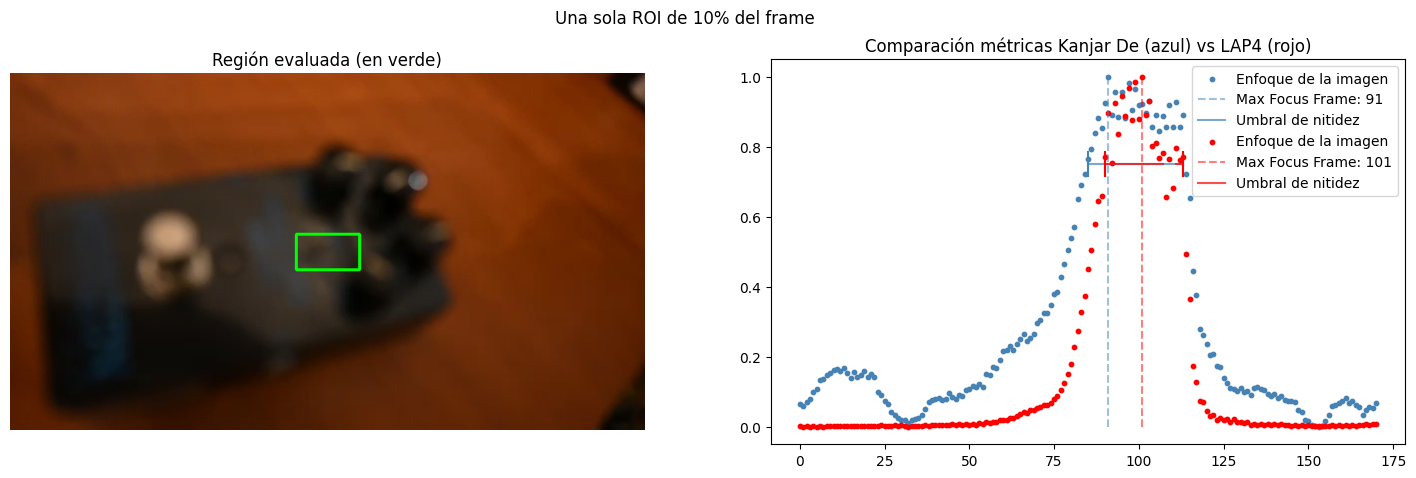

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18,5))

plot_ROIs(bgr_frames[0].copy(), rois2, ax=axes[0])
axes[0].set_title("Región evaluada (en verde)")

# Normalización
fm2_norm = normalizar(fm2)
focus_fm2_norm = define_sharpness_zone(fm2_norm, 0.75)
scores2_norm = normalizar(scores2)
focus_scores2_norm = define_sharpness_zone(scores2_norm, 0.75)
plot_FM(fm2_norm, focus_fm2_norm, ax=axes[1], color='steelblue')
plot_FM(scores2_norm, focus_scores2_norm, ax=axes[1], color='red')
axes[1].set_title("Comparación métricas Kanjar De (azul) vs LAP4 (rojo)")

plt.suptitle("Una sola ROI de 10% del frame")
plt.show()

Umbral: 0.75
Umbral: 0.75


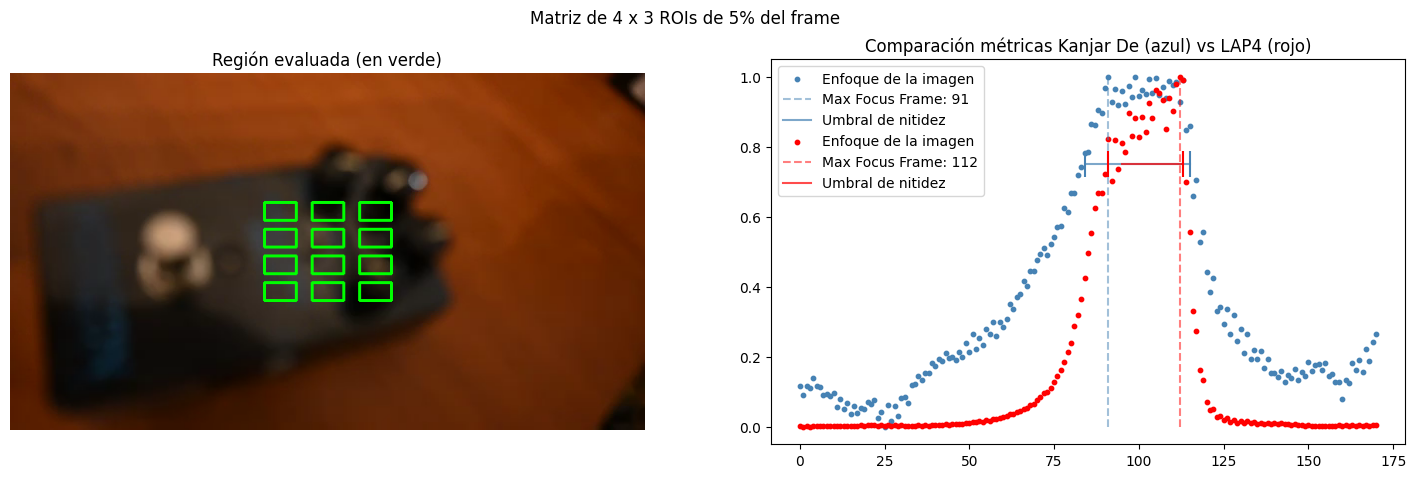

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18,5))

plot_ROIs(bgr_frames[0].copy(), rois3, ax=axes[0])
axes[0].set_title("Región evaluada (en verde)")

# Normalización
fm3_norm = normalizar(fm3)
focus_fm3_norm = define_sharpness_zone(fm3_norm, 0.75)
scores3_norm = normalizar(scores3)
focus_scores3_norm = define_sharpness_zone(scores3_norm, 0.75)
plot_FM(fm3_norm, focus_fm3_norm, ax=axes[1], color='steelblue')
plot_FM(scores3_norm, focus_scores3_norm, ax=axes[1], color='red')
axes[1].set_title("Comparación métricas Kanjar De (azul) vs LAP4 (rojo)")

plt.suptitle("Matriz de 4 x 3 ROIs de 5% del frame")
plt.show()

Umbral: 0.75
Umbral: 0.75


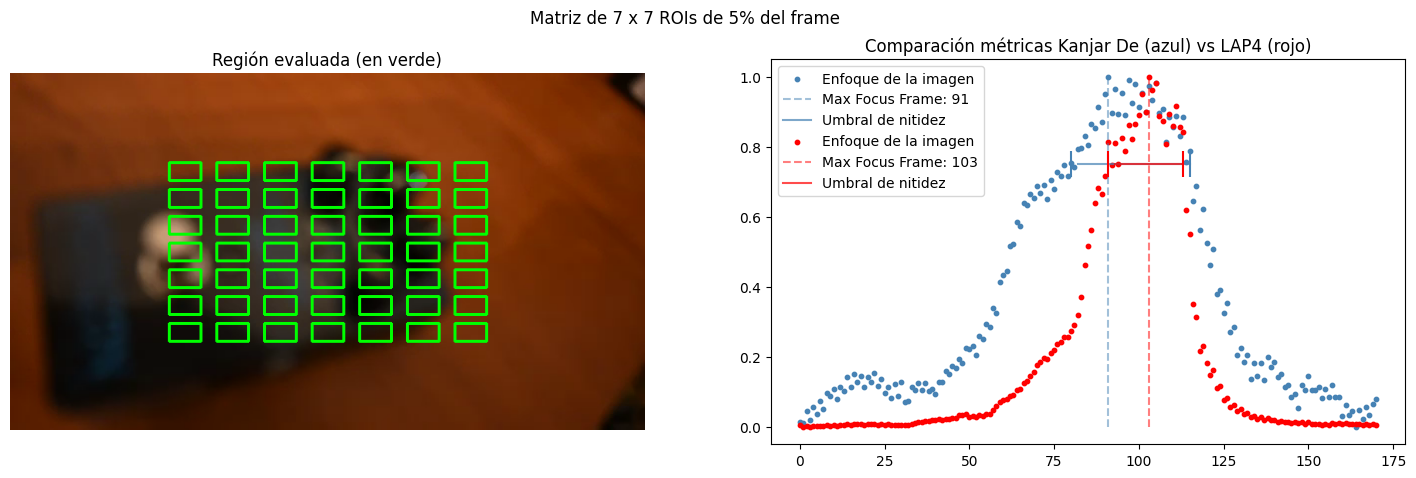

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18,5))

plot_ROIs(bgr_frames[0].copy(), rois4, ax=axes[0])
axes[0].set_title("Región evaluada (en verde)")

# Normalización
fm4_norm = normalizar(fm4)
focus_fm4_norm = define_sharpness_zone(fm4_norm, 0.75)
scores4_norm = normalizar(scores4)
focus_scores4_norm = define_sharpness_zone(scores4_norm, 0.75)
plot_FM(fm4_norm, focus_fm4_norm, ax=axes[1], color='steelblue')
plot_FM(scores4_norm, focus_scores4_norm, ax=axes[1], color='red')
axes[1].set_title("Comparación métricas Kanjar De (azul) vs LAP4 (rojo)")

plt.suptitle("Matriz de 7 x 7 ROIs de 5% del frame")
plt.show()

Umbral: 0.75
Umbral: 0.75


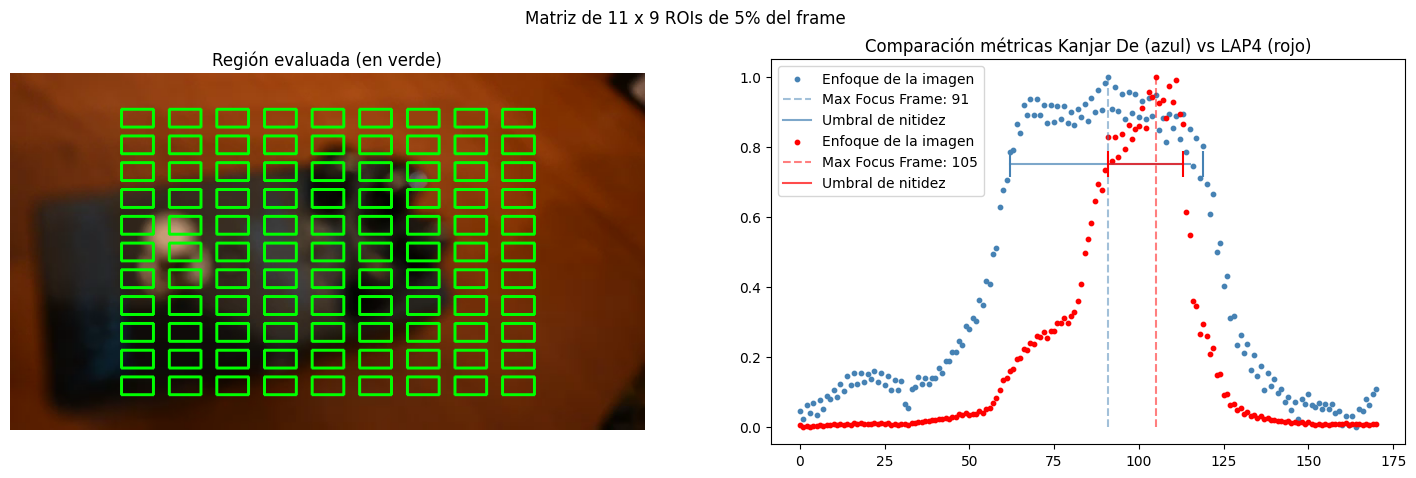

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18,5))

plot_ROIs(bgr_frames[0].copy(), rois5, ax=axes[0])
axes[0].set_title("Región evaluada (en verde)")

# Normalización
fm5_norm = normalizar(fm5)
focus_fm5_norm = define_sharpness_zone(fm5_norm, 0.75)
scores5_norm = normalizar(scores5)
focus_scores5_norm = define_sharpness_zone(scores5_norm, 0.75)
plot_FM(fm5_norm, focus_fm5_norm, ax=axes[1], color='steelblue')
plot_FM(scores5_norm, focus_scores5_norm, ax=axes[1], color='red')
axes[1].set_title("Comparación métricas Kanjar De (azul) vs LAP4 (rojo)")

plt.suptitle("Matriz de 11 x 9 ROIs de 5% del frame")
plt.show()

Se puede ver que la métrica de la varianza de laplacianos es un poco menos susceptible a la región del frame evaluada, y parece oscilar bastante más de un frame a otro continuo, especialmente en la zona de mayor enfoque, lo que complica determinarla con mayor precisión.

También se observa que el primer algoritmo muestra una zona más "ancha" de enfoque, es decir mayor cantidad de frames.

La consigna tambign indica que los algoritmos deben detectar y devolver los puntos de mayor enfoque automáticamente. La función desarrollada solo devuelve la línea de umbral para graficar, por lo cual se implementa la siguiente función para completar el trabajo.

In [20]:
def get_focus_zone(data, th_pcg):
    """
    Devuelve los índices de los frames que superan el umbral dado y el valor de la curva en cada uno de esos frames.
    Args:
        data: lista con la medida de nitidez para cada frame
        th_pcg: porcentaje del valor máximo que se tomará como umbral
    Returns:
        focus_zone: lista de tuplas (índice, valor) con los frames que superan el umbral
    """
    umbral = max(data) * th_pcg
    focus_zone = [(i, data[i]) for i in range(len(data)) if data[i] >= umbral]
    return focus_zone

# Aplicando para una de las evaluaciones realizadas
# focus_zone = get_focus_zone(fm5, 0.75)
# indices, valores = zip(*focus_zone)
# plt.figure(figsize=(10, 5))
# plt.plot(indices, valores)
# plt.xlim(0, len(fm5))

#### Algoritmo final

FPS del video: 29
640  x  360
La zona de máximo enfoque (calculada como aquella hasta un 25% debajo del máximo enfoque) es: 
del frame 59 al frame 122


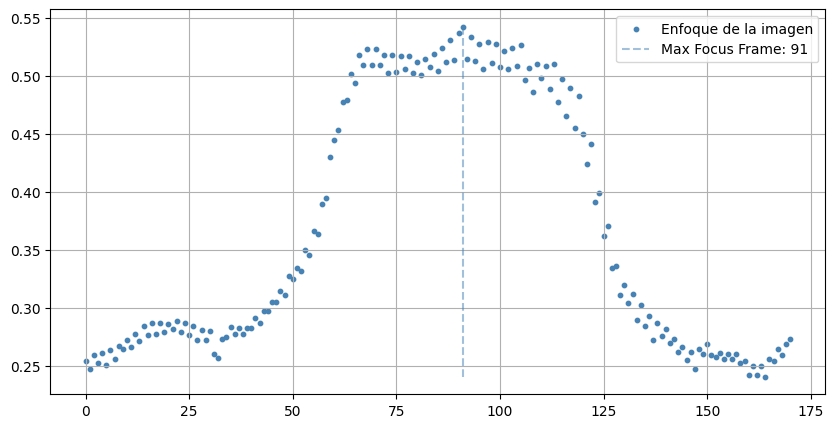

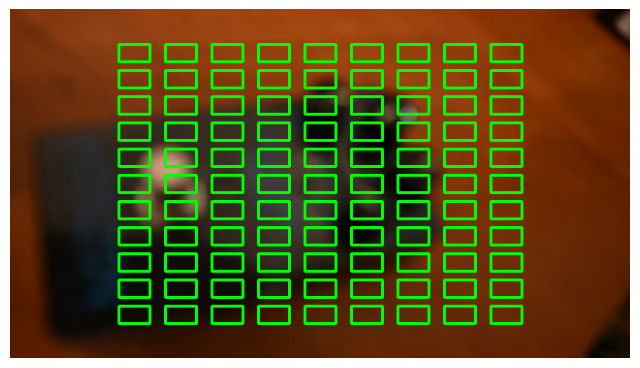

In [21]:
# El procedimiento completo para extraer la zona de máximo enfoque de un video es:

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

video_path = "focus_video.mov"
captura = cv.VideoCapture(video_path)

# Visualizar el video
fps = int(captura.get(cv.CAP_PROP_FPS))
print(f"FPS del video: {fps}")
delay = int(600/fps)

frames = []
bgr_frames = []
if not captura.isOpened():
    print("Error al abrir el video")
else:
    while True:
        ret, frame = captura.read()
        if not ret:
            break
        # cv.imshow("Video", frame)
        # Capturar los frames para después no tener que releer el video
        frames.append(cv.cvtColor(frame, cv.COLOR_BGR2GRAY))
        bgr_frames.append(frame)

        if cv.waitKey(delay) & 0xFF == ord('q'):
            break

frame_width = int(captura.get(cv.CAP_PROP_FRAME_WIDTH))
frame_height = int(captura.get(cv.CAP_PROP_FRAME_HEIGHT))
print(frame_width, " x ", frame_height)
captura.release()
cv.destroyAllWindows()


# Elegir una de las métricas usando evaluate_roi() y evaluate_roi_with_lap4(), mismos parámetros
curve, rois = evaluate_roi(frames, frame_width, frame_height, 11, 9, percentage=0.05, distance=0.5)
# curve, rois = evaluate_roi_with_lap4(frames, frame_width, frame_height, 11, 9, percentage=0.05, distance=0.5)
focus_zone = get_focus_zone(curve, 0.75)
indices, valores = zip(*focus_zone)
plot_FM(curve)
plot_ROIs(bgr_frames[0].copy(), rois)

print("La zona de máximo enfoque (calculada como aquella hasta un 25% debajo del máximo enfoque) es: ")
print(f"del frame {indices[0]} al frame {indices[-1]}")


#### **Puntos extra**: Aplicar unsharp masking para expandir la zona de enfoque y recalcular la métricas.

El algoritmo de unsharp masking consta de los siguientes pasos:
1. Desenfocar la imagen con un filtro suavizador.
$$f(x, y) \rightarrow f_B(x, y)$$
2. Restar la imagen suavizada a la original, obteniendo componentes de alta frecuencia.
$$m(x, y) = f(x, y) - f_B(x, y)$$
3. Agregar el resultado a la imagen original.
$$g(x, y) = f(x, y) + k m(x, y)$$

En una sola fórmula es:
$$g(x, y) = (k + 1)f(x, y) - k f_B(x, y)$$

Se aplicará a los frames cuya métrica se encuentre entre los umbrales del 70% y el 90% del máximo enfoque.

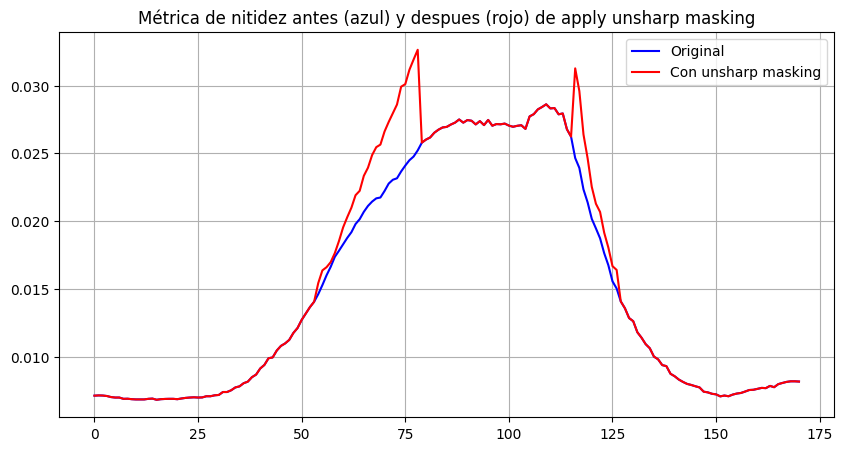

Para una zona de enfoque del 80% del máximo:
Frames enfocados originalmente: De 72 a 117
Frames enfocados después: De 70 a 118


In [46]:
def unsharp_masking(frames_to_sharp, k=1):
    sharped_frames = []
    for frame in frames_to_sharp:
        gaussian_blurred = cv.GaussianBlur(frame, ksize=(5, 5), sigmaX=0)
        sharped = (k + 1) * frame - k * gaussian_blurred
        clipped = np.clip(sharped, 0, 255).astype(np.uint8)
        sharped_frames.append(clipped)
    
    return sharped_frames

curve, rois = evaluate_roi(frames, frame_width, frame_height, 1, 1, percentage=1.0, distance=0.0)
original_focus_zone = get_focus_zone(curve, 0.80)
orig_indices, orig_values = zip(*original_focus_zone)

low = get_focus_zone(curve, 0.50)
low_indices = {i for i, _ in low}
high = get_focus_zone(curve, 0.90)
high_indices = {i for i, _ in high}

# exclusive_low = low_indices - high_indices
# result = [val if i in exclusive_low else None for i, val in low]
result = [(i, val) for i, val in low if i not in high_indices]

frames_to_sharp = [frames[i] for i, _ in result]
sharpened = unsharp_masking(frames_to_sharp, k=1)

frames_with_sharp = frames.copy()
for (i, _), frame_sharpened in zip(result, sharpened):
    frames_with_sharp[i] = frame_sharpened

curve2, rois2 = evaluate_roi(frames_with_sharp, frame_width, frame_height, 1, 1, percentage=1.0, distance=0.0)
sharpened_focus_zone = get_focus_zone(curve2, 0.80)
sharp_indices, sharp_values = zip(*sharpened_focus_zone)

# Graficar métricas juntas para comparar
plt.figure(figsize=(10, 5))
plt.plot(curve, color='blue', label="Original")
plt.plot(curve2, color='red', label="Con unsharp masking")
plt.legend()
plt.title("Métrica de nitidez antes (azul) y despues (rojo) de apply unsharp masking")
plt.grid()
plt.show()

print("Para una zona de enfoque del 80% del máximo:")
print(f"Frames enfocados originalmente: De {orig_indices[0]} a {orig_indices[-1]}")
print(f"Frames enfocados después: De {sharp_indices[0]} a {sharp_indices[-1]}")